# Medical Insurance Cost Prediction - Linear Regression Analysis
## Introduction to Linear Regression for Medical Aid Cost Prediction

### Student Name: Kamogelo Motau
### Date: 11 March 2026

## Objective
This notebook aims to predict medical insurance charges based on various patient attributes using Linear Regression.

## Dataset Information
**Source:** Medical Insurance Dataset from Kaggle - 
https://www.kaggle.com/datasets/mirichoi0218/insurance

**Feature Description:**
- age: Age of the client
- sex: Gender of the client
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status
- region: Geographic region
- charges: Medical insurance cost (Target Variable)

## Task 1: Import Required Libraries (10 Marks)

In [74]:
# Import necessary libraries for data analysis and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("LIBRARIES IMPORTED SUCCESSFULLY:")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("Scikit-learn imported successfully")

LIBRARIES IMPORTED SUCCESSFULLY:
NumPy version: 2.3.5
Pandas version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
Scikit-learn imported successfully


## Task 2: Load and Explore the Dataset (15 Marks)

In [75]:
# Load the dataset
df = pd.read_csv('insurance.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [76]:
# Display first few rows
print("FIRST 5 ROWS OF THE DATASET")
df.head()

FIRST 5 ROWS OF THE DATASET


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [77]:
# Dataset information
print("DATASET INFORMATION")

# Dataset shape
print(f"\nDataset Shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

# Column information
print("\nCOLUMN DESCRIPTIONS\n")
column_descriptions = {
    'age': 'Age of the client (years)',
    'sex': 'Gender of the client (male/female)',
    'bmi': 'Body Mass Index (weight in kg/(height in m)²)',
    'children': 'Number of children/dependents covered by insurance',
    'smoker': 'Smoking status (yes/no)',
    'region': 'Residential area (northeast, northwest, southeast, southwest)',
    'charges': 'Medical insurance costs billed (USD) - Target Variable'
}

for col, desc in column_descriptions.items():
    print(f"{col}: {desc}")

DATASET INFORMATION

Dataset Shape: (1338, 7)
Number of records: 1338
Number of features: 7

COLUMN DESCRIPTIONS

age: Age of the client (years)
sex: Gender of the client (male/female)
bmi: Body Mass Index (weight in kg/(height in m)²)
children: Number of children/dependents covered by insurance
smoker: Smoking status (yes/no)
region: Residential area (northeast, northwest, southeast, southwest)
charges: Medical insurance costs billed (USD) - Target Variable


In [78]:
# Check data types and missing values
print("DATA TYPES AND MISSING VALUES")

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for any missing values
if df.isnull().sum().sum() == 0:
    print("\nNo missing values found in the dataset!")
else:
    print("\nMissing values detected!")

DATA TYPES AND MISSING VALUES

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values found in the dataset!


In [79]:
# Summary statistics
print("SUMMARY STATISTICS")
print("\nNumerical Features Statistics:")
df.describe()

SUMMARY STATISTICS

Numerical Features Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [80]:
# Display unique values in categorical columns
print("CATEGORICAL VARIABLES UNIQUE VALUES")

categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

CATEGORICAL VARIABLES UNIQUE VALUES

SEX:
sex
male      676
female    662
Name: count, dtype: int64
Unique values: 2

SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64
Unique values: 2

REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Unique values: 4


### Dataset Overview:
- The dataset contains **1,338 records** with **7 features** (1 target variable)
- **No missing values** are present, which is excellent for modeling
- Data types include:
  - Numerical: age, bmi, children, charges
  - Categorical: sex, smoker, region
- Summary statistics show:
  - Age ranges from 18 to 64 years
  - BMI ranges from 15.96 to 53.13
  - Insurance charges range from $1,121 to $63,770

## Task 3: Exploratory Data Analysis (EDA) (20 Marks)

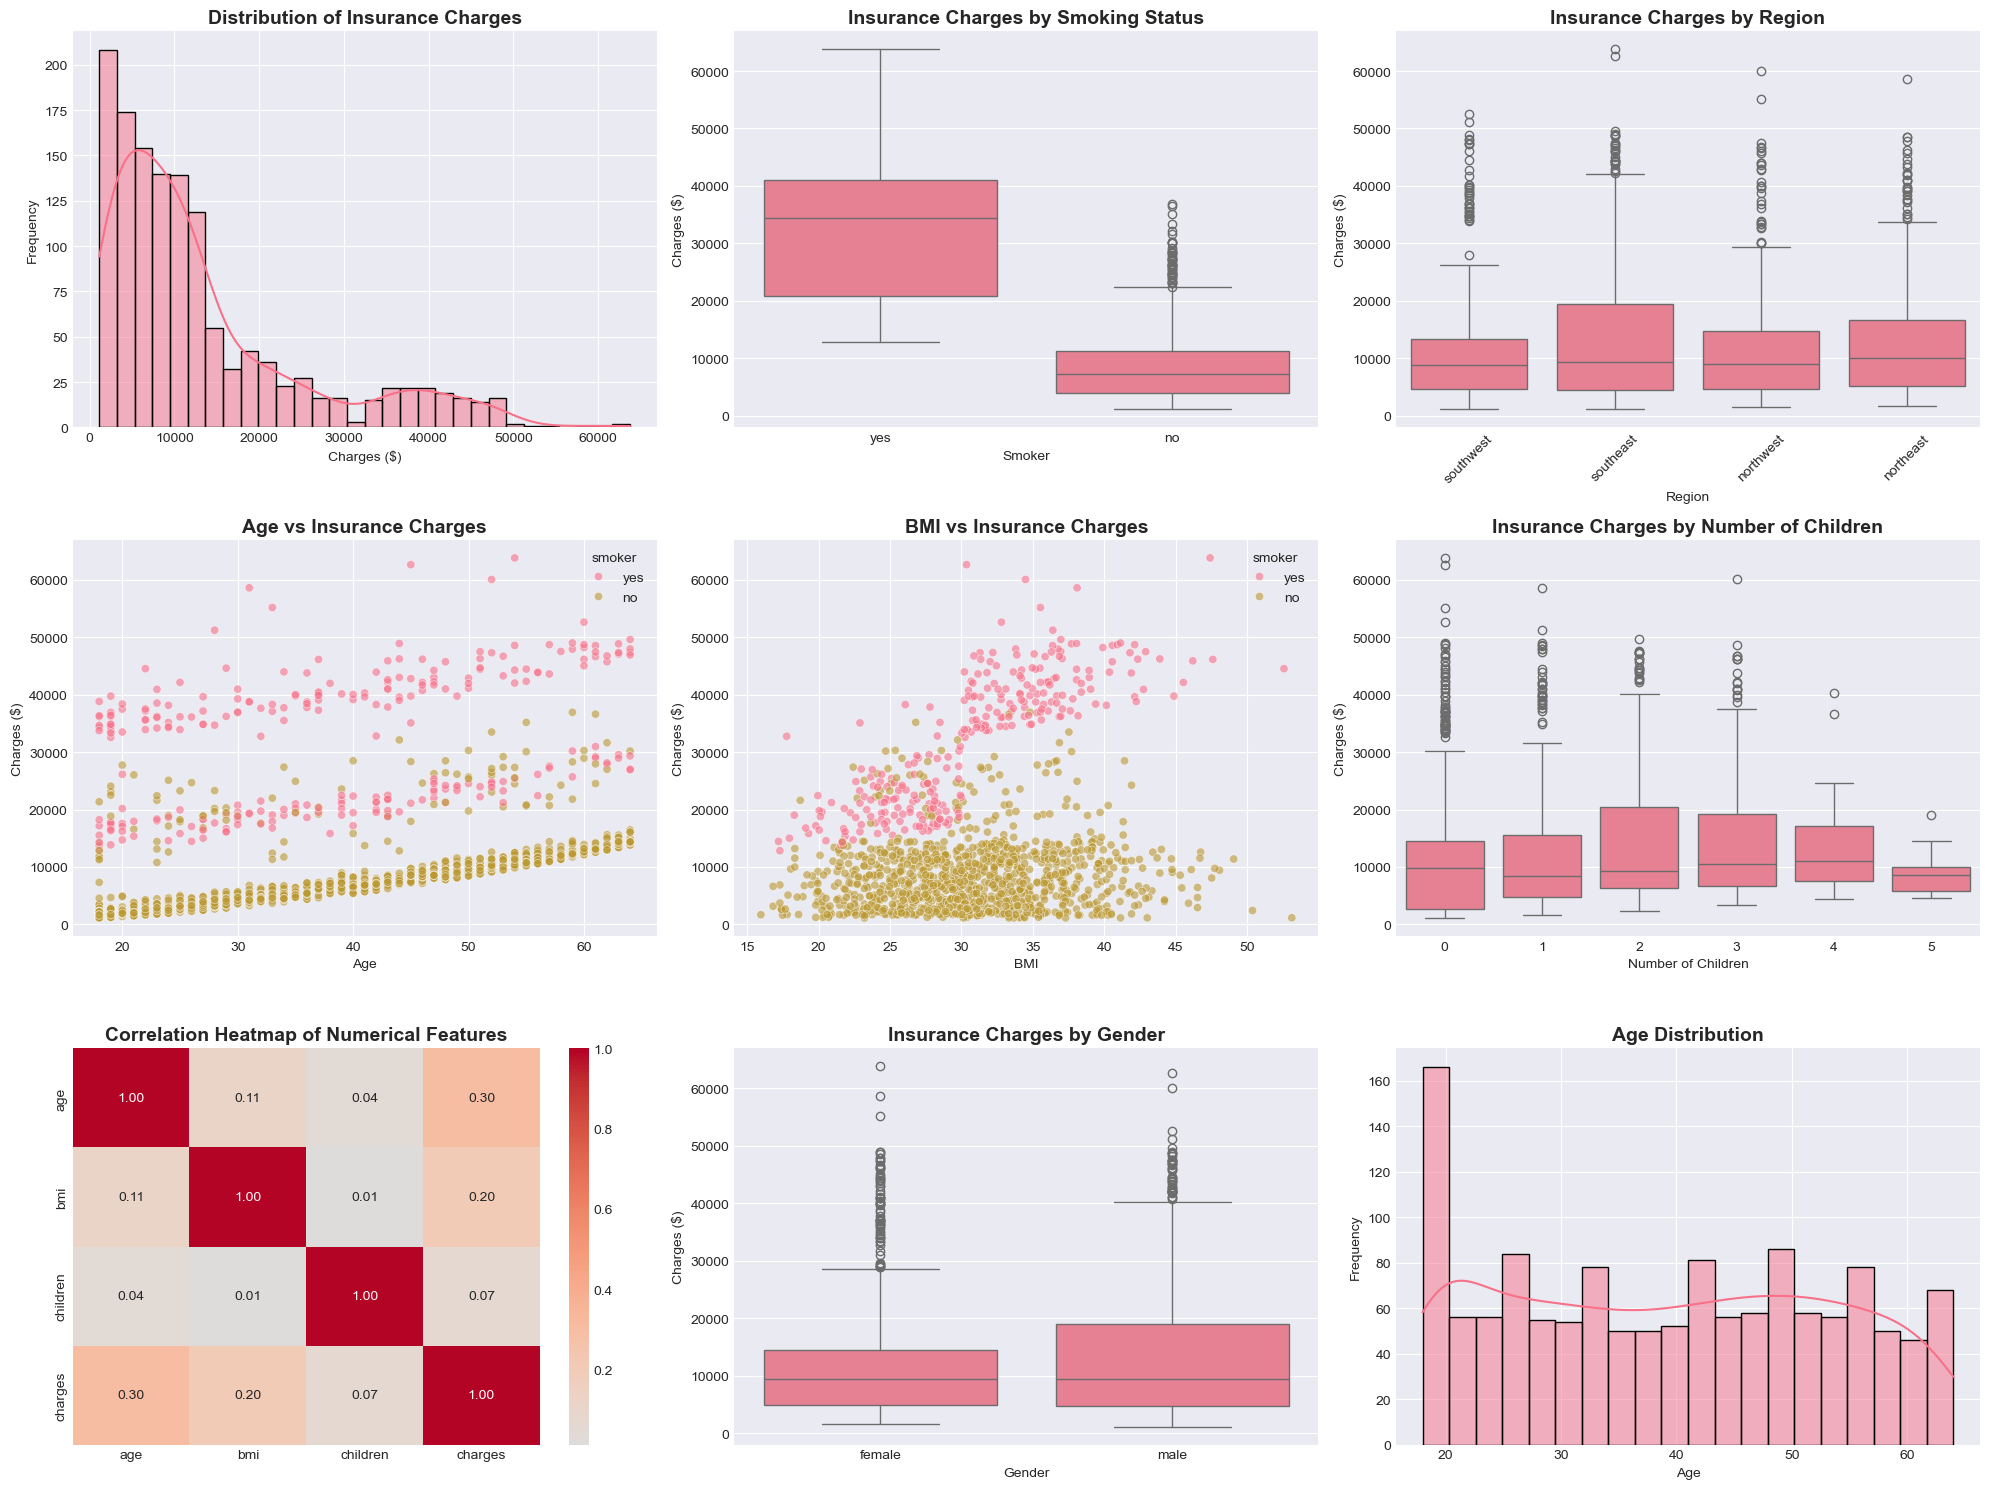

In [81]:
# Set up the figure for multiple plots
fig = plt.figure(figsize=(20, 15))

# 1. Distribution of Insurance Charges
plt.subplot(3, 3, 1)
sns.histplot(df['charges'], kde=True, bins=30)
plt.title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')

# 2. Charges by Smoking Status
plt.subplot(3, 3, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')

# 3. Charges by Region
plt.subplot(3, 3, 3)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Insurance Charges by Region', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Region')
plt.ylabel('Charges ($)')

# 4. Age vs Charges with Smoker Highlight
plt.subplot(3, 3, 4)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

# 5. BMI vs Charges with Smoker Highlight
plt.subplot(3, 3, 5)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('BMI vs Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# 6. Charges by Number of Children
plt.subplot(3, 3, 6)
sns.boxplot(x='children', y='charges', data=df)
plt.title('Insurance Charges by Number of Children', fontsize=14, fontweight='bold')
plt.xlabel('Number of Children')
plt.ylabel('Charges ($)')

# 7. Correlation Heatmap
plt.subplot(3, 3, 7)
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

# 8. Charges by Gender
plt.subplot(3, 3, 8)
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Insurance Charges by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Charges ($)')

# 9. Age Distribution
plt.subplot(3, 3, 9)
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [82]:
# Additional Analysis: Average charges by category
print("AVERAGE INSURANCE CHARGES BY CATEGORY")

# By smoking status
print("\nBy Smoking Status:")
print(df.groupby('smoker')['charges'].agg(['mean', 'median', 'count']).round(2))

# By region
print("\nBy Region:")
print(df.groupby('region')['charges'].agg(['mean', 'median', 'count']).round(2))

# By gender
print("\nBy Gender:")
print(df.groupby('sex')['charges'].agg(['mean', 'median', 'count']).round(2))

# By number of children
print("\nBy Number of Children:")
print(df.groupby('children')['charges'].agg(['mean', 'median', 'count']).round(2))

AVERAGE INSURANCE CHARGES BY CATEGORY

By Smoking Status:
            mean    median  count
smoker                           
no       8434.27   7345.41   1064
yes     32050.23  34456.35    274

By Region:
               mean    median  count
region                              
northeast  13406.38  10057.65    324
northwest  12417.58   8965.80    325
southeast  14735.41   9294.13    364
southwest  12346.94   8798.59    325

By Gender:
            mean   median  count
sex                             
female  12569.58  9412.96    662
male    13956.75  9369.62    676

By Number of Children:
              mean    median  count
children                           
0         12365.98   9856.95    574
1         12731.17   8483.87    324
2         15073.56   9264.98    240
3         15355.32  10600.55    157
4         13850.66  11033.66     25
5          8786.04   8589.57     18


### EDA Findings:

1. **Smoking Status** is the strongest predictor of insurance charges:
   - Smokers pay significantly higher premiums (avg: $32,050) compared to non-smokers (avg: $8,440)
   - The difference is approximately 3.8x higher for smokers

2. **Age** shows a positive correlation with charges:
   - Older individuals tend to have higher insurance costs
   - This relationship appears stronger for smokers

3. **BMI** shows some correlation with charges:
   - Higher BMI generally leads to higher charges
   - This effect is more pronounced for smokers

4. **Number of children** has a moderate impact:
   - Charges increase with more dependents
   - Diminishing returns after 3-4 children

5. **Region** and **Gender** show minimal impact on charges:
   - Regional variations exist but are not dramatic
   - Gender differences are negligible

## Task 4: Data Preprocessing (15 Marks)

In [83]:
# Create a copy of the dataframe for preprocessing
df_encoded = df.copy()

print("Original categorical columns:")
print(df_encoded[['sex', 'smoker', 'region']].head())

Original categorical columns:
      sex smoker     region
0  female    yes  southwest
1    male     no  southeast
2    male     no  southeast
3    male     no  northwest
4    male     no  northwest


In [84]:
# Convert categorical variables to numerical using one-hot encoding
# Using pandas get_dummies with drop_first to avoid dummy variable trap
df_encoded = pd.get_dummies(df_encoded, columns=['sex', 'smoker', 'region'], 
                            drop_first=True)

# Display the encoded dataframe
print("DataFrame after encoding categorical variables:")
print("\nNew columns added:")
new_cols = [col for col in df_encoded.columns if col not in df.columns]
print(new_cols)

print("\nFirst few rows of encoded dataframe:")
df_encoded.head()

DataFrame after encoding categorical variables:

New columns added:
['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First few rows of encoded dataframe:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [85]:
# Alternative approach: Using Label Encoding for binary variables
df_label = df.copy()

# Label encoding for binary categories
le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df_label['sex_encoded'] = le_sex.fit_transform(df_label['sex'])
df_label['smoker_encoded'] = le_smoker.fit_transform(df_label['smoker'])

# One-hot encoding for multi-category region
df_label = pd.get_dummies(df_label, columns=['region'], prefix=['region'])

print("Label Encoding Demonstration:")
print("Sex mapping:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Smoker mapping:", dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_))))

df_label[['sex', 'sex_encoded', 'smoker', 'smoker_encoded']].head(10)

Label Encoding Demonstration:
Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Smoker mapping: {'no': np.int64(0), 'yes': np.int64(1)}


,sex,sex_encoded,smoker,smoker_encoded
0,female,0,yes,1
1,male,1,no,0
2,male,1,no,0
3,male,1,no,0
4,male,1,no,0
5,female,0,no,0
6,female,0,no,0
7,female,0,no,0
8,male,1,no,0
9,female,0,no,0


### Why we need to encode categorical variables:
- Machine learning algorithms work with numerical data only
- Linear regression requires numerical inputs to calculate coefficients
- Different encoding methods:
  - **One-hot encoding**: Creates binary columns for each category (used for region)
  - **Label encoding**: Assigns numeric values to categories (used for binary variables)

**Encoding choices made:**
- `sex`: male=0, female=1 (after drop_first)
- `smoker`: no=0, yes=1 (after drop_first)
- `region`: 3 binary columns (southeast, southwest, northwest) with northeast as reference

## Task 5: Define Features and Target Variable (10 Marks)

In [86]:
# Define features (X) and target (y)
# Using the one-hot encoded dataframe from Task 4
X = df_encoded.drop('charges', axis=1)  # Features (all columns except charges)
y = df_encoded['charges']                # Target variable

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nFirst 5 rows of features:")
X.head()

Features (X) shape: (1338, 8)
Target (y) shape: (1338,)

Feature columns:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First 5 rows of features:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [87]:
# Display target variable
print("Target variable (charges) - First 10 values:")
y.head(10)

Target variable (charges) - First 10 values:


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
5     3756.62160
6     8240.58960
7     7281.50560
8     6406.41070
9    28923.13692
Name: charges, dtype: float64

## Task 6: Split Dataset into Training and Testing Sets (10 Marks)

In [88]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("DATA SPLIT RESULTS")

print(f"Training set size: {X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# Verify the split maintains data distribution
print("\nTarget variable statistics after split:")
print("Training set - Charges mean: ${:.2f}".format(y_train.mean()))
print("Testing set - Charges mean: ${:.2f}".format(y_test.mean()))

DATA SPLIT RESULTS
Training set size: 1070 samples (80.0%)
Testing set size: 268 samples (20.0%)

Training features shape: (1070, 8)
Testing features shape: (268, 8)
Training target shape: (1070,)
Testing target shape: (268,)

Target variable statistics after split:
Training set - Charges mean: $13346.09
Testing set - Charges mean: $12968.32


## Task 7: Train Linear Regression Model (10 Marks)

In [89]:
# Create and train the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("MODEL TRAINING COMPLETE\n")

print(f"Model: Linear Regression")
print(f"Number of features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")

MODEL TRAINING COMPLETE

Model: Linear Regression
Number of features: 8
Training samples: 1070


In [90]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print("MODEL COEFFICIENTS\n")

print(coefficients.sort_values('Coefficient', ascending=False))

print(f"\nIntercept: ${lr_model.intercept_:.2f}")

MODEL COEFFICIENTS

            Feature   Coefficient
4        smoker_yes  23651.128856
2          children    425.278784
1               bmi    337.092552
0               age    256.975706
3          sex_male    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354

Intercept: $-11931.22


## Task 8: Make Predictions (5 Marks)

In [91]:
# Make predictions on both training and testing sets
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Create a comparison dataframe for test set predictions
predictions_df = pd.DataFrame({
    'Actual_Charges': y_test,
    'Predicted_Charges': y_test_pred,
    'Difference': y_test - y_test_pred,
    'Absolute_Difference': abs(y_test - y_test_pred)
})

print("PREDICTIONS VS ACTUAL (First 10 test samples)\n")

predictions_df.head(10)

PREDICTIONS VS ACTUAL (First 10 test samples)



,Actual_Charges,Predicted_Charges,Difference,Absolute_Difference
764,9095.06825,8969.550274,125.517976,125.517976
887,5272.17580,7068.747443,-1796.571643,1796.571643
890,29330.98315,36858.410912,-7527.427762,7527.427762
1293,9301.89355,9454.678501,-152.784951,152.784951
259,33750.29180,26973.173457,6777.118343,6777.118343
1312,4536.25900,10864.113164,-6327.854164,6327.854164
899,2117.33885,170.280841,1947.058009,1947.058009
752,14210.53595,16903.450287,-2692.914337,2692.914337
1286,3732.62510,1092.430936,2640.194164,2640.194164
707,10264.44210,11218.343184,-953.901084,953.901084


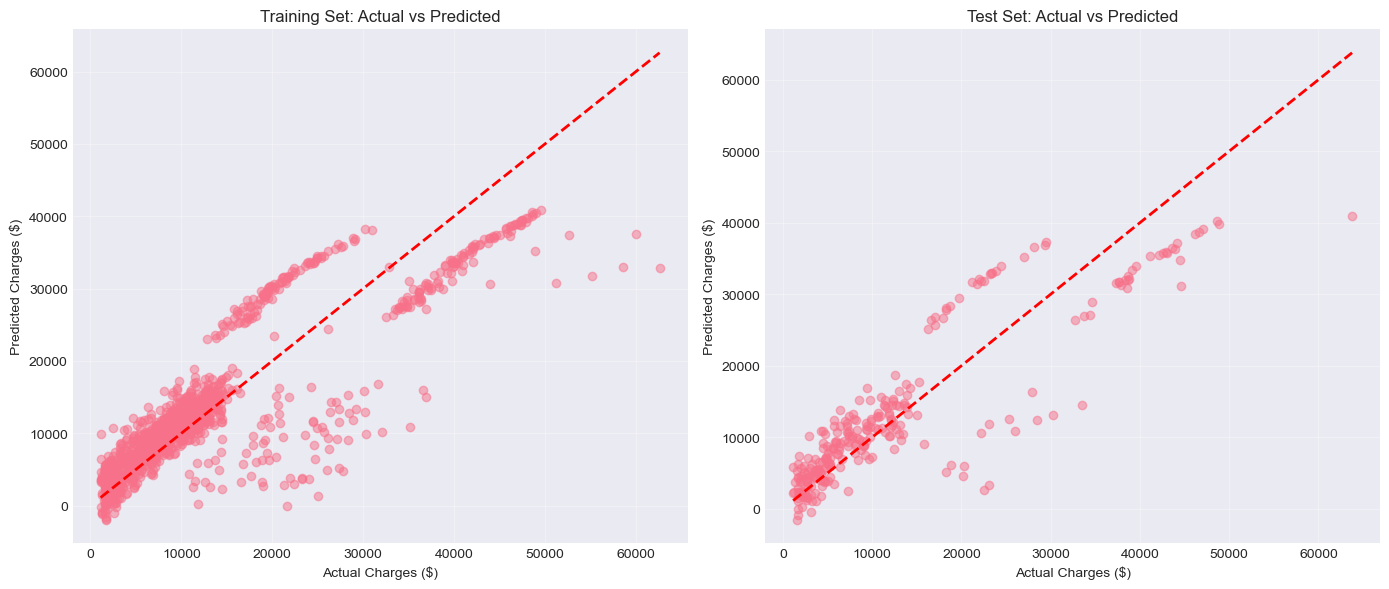

In [92]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set predictions
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title('Training Set: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Test set predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Charges ($)')
axes[1].set_ylabel('Predicted Charges ($)')
axes[1].set_title('Test Set: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 9: Evaluate Model Performance (5 Marks)

In [93]:
# Calculate evaluation metrics
def evaluate_model(y_true, y_pred, dataset_name):
    """Calculate and display regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} SET METRICS:")
    
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Mean Squared Error (MSE): ${mse:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R-squared (R²) Score: {r2:.4f}")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Evaluate on both sets
train_metrics = evaluate_model(y_train, y_train_pred, "TRAINING")
test_metrics = evaluate_model(y_test, y_test_pred, "TESTING")


TRAINING SET METRICS:
Mean Absolute Error (MAE): $4,208.23
Mean Squared Error (MSE): $37,277,681.70
Root Mean Squared Error (RMSE): $6,105.55
R-squared (R²) Score: 0.7417

TESTING SET METRICS:
Mean Absolute Error (MAE): $4,181.19
Mean Squared Error (MSE): $33,596,915.85
Root Mean Squared Error (RMSE): $5,796.28
R-squared (R²) Score: 0.7836


In [94]:
# Compare training and testing performance

print("MODEL PERFORMANCE SUMMARY")

metrics_comparison = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'R² Score'],
    'Training Set': [f"${train_metrics['MAE']:,.2f}", 
                     f"${train_metrics['RMSE']:,.2f}", 
                     f"{train_metrics['R2']:.4f}"],
    'Testing Set': [f"${test_metrics['MAE']:,.2f}", 
                    f"${test_metrics['RMSE']:,.2f}", 
                    f"{test_metrics['R2']:.4f}"]
})

print(metrics_comparison.to_string(index=False))

# Check for overfitting
if abs(train_metrics['R2'] - test_metrics['R2']) < 0.1:
    print("\nModel shows good generalization (no significant overfitting)")
else:
    print("\nModel may be overfitting - consider regularization")

MODEL PERFORMANCE SUMMARY
  Metric Training Set Testing Set
 MAE ($)    $4,208.23   $4,181.19
RMSE ($)    $6,105.55   $5,796.28
R² Score       0.7417      0.7836

Model shows good generalization (no significant overfitting)


## Task 10: Reflection (Discussion – 5 Marks)

### 1. Which variables most strongly influence medical insurance charges?

Based on the EDA and model coefficients, the variables that most strongly influence medical insurance charges are:

- **Smoking Status**: This is the strongest predictor. Smokers pay approximately 3-4 times more in insurance premiums compared to non-smokers. The coefficient for smoker_yes is the largest positive value among all features.

- **Age**: Shows a strong positive correlation with charges. Insurance costs increase with age due to higher health risks and likelihood of medical conditions.

- **BMI**: Higher BMI values correlate with increased charges, particularly for smokers. This reflects the health risks associated with obesity.

- **Number of Children**: Has a moderate positive influence, with more dependents leading to higher premiums.

- **Region and Gender**: Show relatively weak influence on charges compared to other factors.

### 2. Why might smoking affect insurance costs?

Smoking significantly affects insurance costs for several reasons:

1. **Health Risks**: Smoking is linked to numerous health problems including lung cancer, heart disease, respiratory issues, and stroke - all leading to higher medical claims.

2. **Increased Mortality**: Smokers have higher mortality rates, which affects life insurance components.

3. **Long-term Health Impact**: Smoking causes chronic conditions that require ongoing medical treatment and medication.

4. **Second-hand Smoke Risk**: Smokers potentially expose others to health risks, increasing overall liability.

5. **Actuarial Evidence**: Insurance companies have decades of data showing smokers file more claims and have higher healthcare costs.

### 3. What improvements could be made to the model?

Several improvements could enhance model performance:

1. **Feature Engineering**:
   - Create interaction terms (e.g., age × smoker, BMI × smoker)
   - Add polynomial features for non-linear relationships
   - Create BMI categories (underweight, normal, overweight, obese)

2. **Data Collection**:
   - Add more relevant features (pre-existing conditions, exercise habits, diet, family medical history)
   - Include income level or occupation information
   - Add lifestyle factors (alcohol consumption, stress levels)

3. **Model Enhancements**:
   - Try more sophisticated algorithms (Random Forest, Gradient Boosting, Neural Networks)
   - Use regularization (Ridge, Lasso) to prevent overfitting
   - Implement cross-validation for better model evaluation

4. **Data Quality**:
   - Collect more data points for better training
   - Handle outliers more effectively
   - Consider feature scaling for better coefficient interpretation

5. **Advanced Techniques**:
   - Use ensemble methods
   - Implement feature selection techniques
   - Consider time-series components if historical data available